In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
import json
import os

os.chdir("../")
from scripts import utils, alerceanomalies
import matplotlib.gridspec as gridspec
from tqdm.auto import tqdm

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

from sklearn.svm import OneClassSVM
import distclassipy as dcpy
from distclassipy.anomaly import DistanceAnomaly
from sklearn.model_selection import train_test_split

from sklearn.base import BaseEstimator, OutlierMixin
epsilon = np.finfo(np.float32).eps
with open("settings.txt") as f:
    settings_dict = json.load(f)
seed_val = settings_dict["seed_choice"]
np.random.seed(seed_val)
sns_dict = settings_dict["sns_dict"]
sns.set_theme(**sns_dict)

from IPython.core.display import HTML
from IPython.display import display

import squarify
set3colors = [matplotlib.colors.rgb2hex(x) for x in plt.cm.Set3.colors]
knowncolors = set3colors[:4]
unknowncolors = ['#e6194B', '#3cb44b', '#ffe119', '#4363d8', '#f58231', '#911eb4', '#42d4f4', '#f032e6', '#bfef45', '#fabed4', '#469990', '#dcbeff', '#9A6324', '#fffac8', '#800000', '#aaffc3', '#808000', '#ffd8b1', '#000075', '#a9a9a9']
unknowncolors = set3colors[4:]+unknowncolors

from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.preprocessing import StandardScaler

In [2]:
# Create a dictionary of all models to test
models_to_test = {
    "DistClassiPy (min-median)": DistanceAnomaly(
        cluster_agg='min',
        metric_agg='median',
        normalize_scores=True
    ),
    
    "DistClassiPy (min-mean)": DistanceAnomaly(
        cluster_agg='min',
        metric_agg='mean',
        normalize_scores=True
    ),

    "IsolationForest": IsolationForest( #using alerce anomaly params
        n_estimators=100,
        max_samples=256,
        contamination=0.001,
        random_state=seed_val+2
    ),
    "LocalOutlierFactor": LocalOutlierFactor(
        n_neighbors=20, 
        novelty=True,  # IMPORTANT: Allows use on new data
        contamination='auto'
    ),
    
    "OneClassSVM": OneClassSVM(
        kernel='rbf',
        nu=0.001
    ),

    "Autoencoder": alerceanomalies.AutoencoderAnomalyDetector(
        encoding_dim=32, # Can be tuned
        epochs=200,
        patience=10,
    ),


    "Variational Autoencoder": alerceanomalies.VAEAnomalyDetector(
        encoding_dim=32, # Can be tuned
        epochs=200,
        patience=10,
        loss_samples=5 # Number of samples for the reconstruction term in ELBO
    ),

    "DeepSVDD": alerceanomalies.DeepSVDDAnomalyDetector(
        encoding_dim=32, # Can be tuned
        epochs=200,
        patience=10,
    ),

    "ClassSVDD": alerceanomalies.ClassSVDDAnomalyDetector(
        z_dim=64,
        epochs=250,
        patience=15,
        lr=1e-4,
        verbose=False
    )
}

In [3]:
traindat = pd.read_pickle("data/alercedata/train_data_filtered.pkl").set_index("oid")
testdat = pd.read_pickle("data/alercedata/test_data_filtered.pkl").set_index("oid")
feature_list = pd.read_pickle("data/alercedata/features_BHRF_model.pkl")

commondat = pd.concat([traindat,testdat])
commondat=commondat.rename(columns={"classALeRCE":"class"})

#### RESAMPLE
# commondat=commondat.groupby('class').apply(lambda x: x.sample(n=min(3000,len(x)), random_state=seed_val)).reset_index(drop=True) 

In [4]:
def run_anom_exp(new_knowns, new_unknowns,features_to_use,std_scale, rebalance_knowns):
    subclasses = np.concatenate([new_knowns, new_unknowns])
    top_level_df = commondat[commondat['class'].isin(subclasses)]
    top_level_df = top_level_df.loc[:,list(features_to_use)+["class"]].dropna(subset=features_to_use)
    top_level_df = top_level_df[~top_level_df.index.duplicated(keep='first')]
    
    inlier_df = top_level_df[top_level_df["class"].isin(myknowns)]
    if rebalance_knowns:
        smallest_class_count = inlier_df["class"].value_counts().min()
        inlier_df = inlier_df.groupby("class").sample(smallest_class_count)
        
    outlier_df = top_level_df[top_level_df["class"].isin(myunknowns)]

    if len(outlier_df) == 0:
        raise(f"\tSkipping {anomaly_subclass}, no samples found.")
        

    # First split inliers into train/test
    inlier_train_df, inlier_test_df = train_test_split(
        inlier_df, test_size=0.2, random_state=seed_val,
        stratify=inlier_df['class'],
    )
    
    X_train_df = inlier_train_df[features_to_use]
    X_train = X_train_df.to_numpy()
    y_train_df = inlier_train_df['class']
    y_train = y_train_df.to_numpy()

    # Add outliers to test only
    X_test_inliers_df = inlier_test_df[features_to_use]
    X_test_outliers_df = outlier_df[features_to_use]
    X_test_df = pd.concat([X_test_inliers_df, X_test_outliers_df])
    X_test = X_test_df.to_numpy()

    y_test_df = top_level_df.loc[X_test_df.index,"class"]
    y_test = y_test_df.to_numpy()

    results_df = pd.DataFrame(index=X_test_df.index)
    results_df['class'] = y_test_df
    mask = results_df['class'].isin(new_knowns)
    results_df['status'] = np.where(mask, 'normal', 'anomalous')
    
    # # STD SCALER
    if std_scale:
        scaler = StandardScaler()
        X_train = scaler.fit_transform(X_train)
        X_test = scaler.transform(X_test)

    for model_name, model in tqdm(models_to_test.items(), desc=f"Models", leave=False):
        if "DistClassiPy" in model_name or "ClassSVDD" in model_name or "DeepSVDD" in model_name:
            model.fit(X_train, y_train)
        else:
            model.fit(X_train)
        scores = model.decision_function(X_test)
        if model_name in ["IsolationForest", "LocalOutlierFactor", "OneClassSVM"]:
            scores = -scores # Lower is more anomalous for these, so we flip

        results_df[f'score_{model_name}'] = scores

    return results_df

In [5]:
def analysis(results_df, min_to_plot=200):

    # --- 1. Plot for purity v/s budget ---
    max_anom = results_df["status"].value_counts()["anomalous"]
    top_n = min(min_to_plot, max_anom)
        
    methods_percent = {}
    top_ns = np.arange(start=1, stop=top_n+1)
    
    for model_name in tqdm(models_to_test.keys(),desc="method",leave=False):
        methods_percent[model_name] = []
        topresults_df = results_df.sort_values(by=f"score_{model_name}",ascending=False).iloc[:top_n]
        for i in tqdm(range(len(topresults_df)), leave=False):
            top_candidates = topresults_df.head(i)
            valcounts = top_candidates['status'].value_counts(normalize=True,ascending=True)
            if "anomalous" in valcounts.index:
                frac = valcounts["anomalous"]
                # frac = valcounts["anomalous"] / len(y_anom_df)
            else:
                frac = 0
            methods_percent[model_name].append(frac)
        
        lw = 4 if "DistClassiPy" in model_name else 1
        plt.plot(top_ns, methods_percent[model_name][:top_n], label=model_name, linewidth=lw)
    plt.ylabel("Purity", fontsize=16)
    plt.xlabel("Follow-up Budget (No. of sources)", fontsize=16)
    plt.gca().tick_params(axis='both', which='major', labelsize=16)
    plt.gca().tick_params(axis='both', which='minor', labelsize=12)
    plt.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=12)
    # plt.savefig(f"top{endnum}budget4methods.png",dpi=300,bbox_inches="tight")
    return plt.gca()

In [6]:
myfeatures = [
"SPM_A_1",
"SPM_t0_1",
"SPM_gamma_1",
"SPM_beta_1",
"SPM_tau_rise_1",
"SPM_tau_fall_1",
"SPM_chi_1",
"SPM_A_2",
"SPM_t0_2",
"SPM_gamma_2",
"SPM_beta_2",
"SPM_tau_rise_2",
"SPM_tau_fall_2",
"SPM_chi_2",
]

alerce_taxonomy = {
    "Transient": ["SLSN", "SNII", "SNIa", "SNIbc"],
    "Stochastic": ["QSO", "YSO", "AGN", "Blazar", "CV/Nova"],
    "Periodic": ["CEP",  "DSCT", "E", "RRL", "LPV"],
    "All": [
        "SLSN", "SNII", "SNIa", "SNIbc", 
        "QSO", "YSO", "AGN", "Blazar", "CV/Nova",
        "CEP",  "DSCT", "E", "RRL", "LPV"
    ]
}

******************** Transient ********************
Knowns: ['SNII', 'SNIa', 'SNIbc']
Unknowns: ['SLSN']


Models:   0%|          | 0/9 [00:00<?, ?it/s]

Training AE:   0%|          | 0/200 [00:00<?, ?it/s]

Early stopping triggered.


Training VAE:   0%|          | 0/200 [00:00<?, ?it/s]

...

  0%|          | 0/75 [00:00<?, ?it/s]

  0%|          | 0/75 [00:00<?, ?it/s]

  0%|          | 0/75 [00:00<?, ?it/s]

  0%|          | 0/75 [00:00<?, ?it/s]

  0%|          | 0/75 [00:00<?, ?it/s]

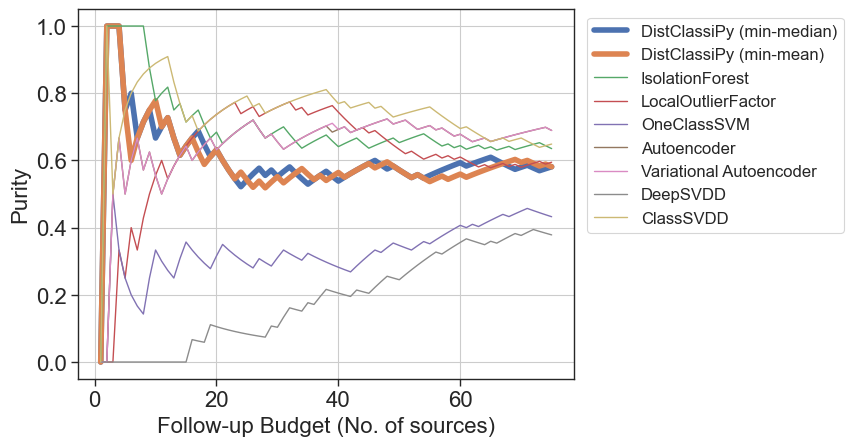

Knowns: ['SLSN', 'SNIa', 'SNIbc']
Unknowns: ['SNII']


Models:   0%|          | 0/9 [00:00<?, ?it/s]

/Users/sidchaini/miniconda3/lib/python3.12/site-packages/sklearn/ensemble/_iforest.py:336: UserWarning: max_samples (256) is greater than the total number of samples (180). max_samples will be set to n_samples for estimation.
  warn(


Training AE:   0%|          | 0/200 [00:00<?, ?it/s]

Early stopping triggered.


...

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

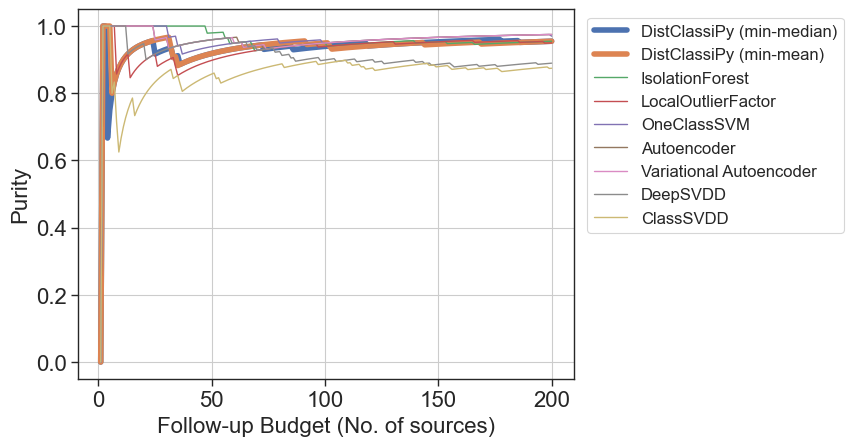

Knowns: ['SLSN', 'SNII', 'SNIbc']
Unknowns: ['SNIa']


Models:   0%|          | 0/9 [00:00<?, ?it/s]

/Users/sidchaini/miniconda3/lib/python3.12/site-packages/sklearn/ensemble/_iforest.py:336: UserWarning: max_samples (256) is greater than the total number of samples (180). max_samples will be set to n_samples for estimation.
  warn(


Training AE:   0%|          | 0/200 [00:00<?, ?it/s]

Early stopping triggered.


...

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

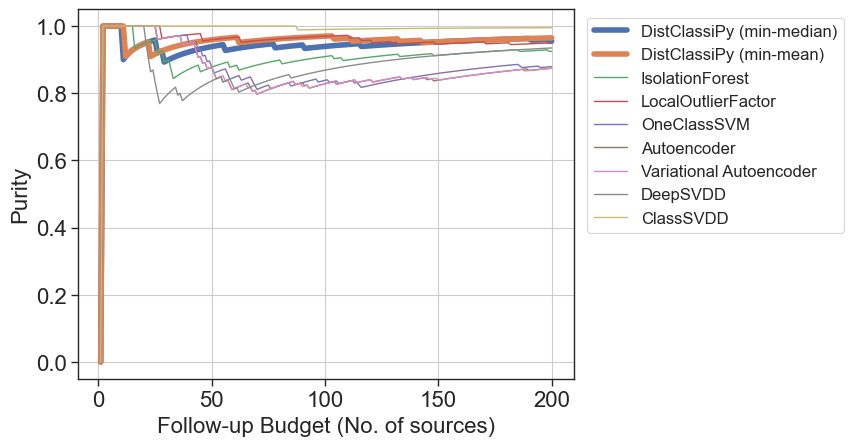

Knowns: ['SLSN', 'SNII', 'SNIa']
Unknowns: ['SNIbc']


Models:   0%|          | 0/9 [00:00<?, ?it/s]

/Users/sidchaini/miniconda3/lib/python3.12/site-packages/sklearn/ensemble/_iforest.py:336: UserWarning: max_samples (256) is greater than the total number of samples (180). max_samples will be set to n_samples for estimation.
  warn(


Training AE:   0%|          | 0/200 [00:00<?, ?it/s]

Early stopping triggered.


...

  0%|          | 0/131 [00:00<?, ?it/s]

  0%|          | 0/131 [00:00<?, ?it/s]

  0%|          | 0/131 [00:00<?, ?it/s]

  0%|          | 0/131 [00:00<?, ?it/s]

  0%|          | 0/131 [00:00<?, ?it/s]

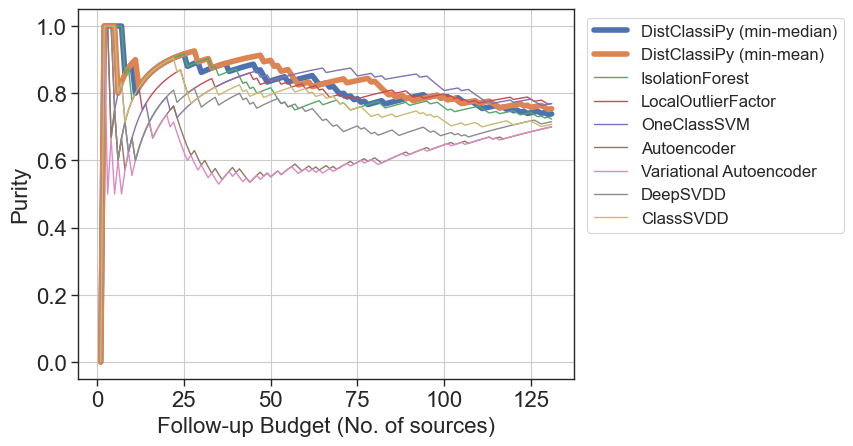

******************** Stochastic ********************
Knowns: ['YSO', 'AGN', 'Blazar', 'CV/Nova']
Unknowns: ['QSO']


Models:   0%|          | 0/9 [00:00<?, ?it/s]

Training AE:   0%|          | 0/200 [00:00<?, ?it/s]

Early stopping triggered.


Training VAE:   0%|          | 0/200 [00:00<?, ?it/s]

...

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

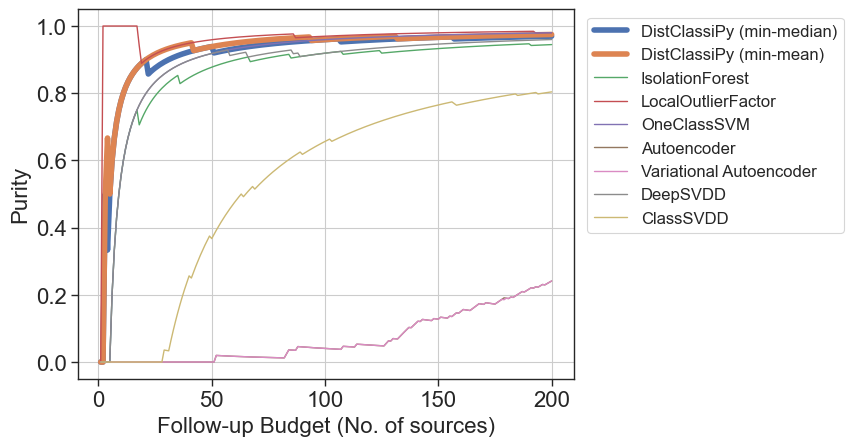

Knowns: ['QSO', 'AGN', 'Blazar', 'CV/Nova']
Unknowns: ['YSO']


Models:   0%|          | 0/9 [00:00<?, ?it/s]

Training AE:   0%|          | 0/200 [00:00<?, ?it/s]

Early stopping triggered.


Training VAE:   0%|          | 0/200 [00:00<?, ?it/s]

...

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

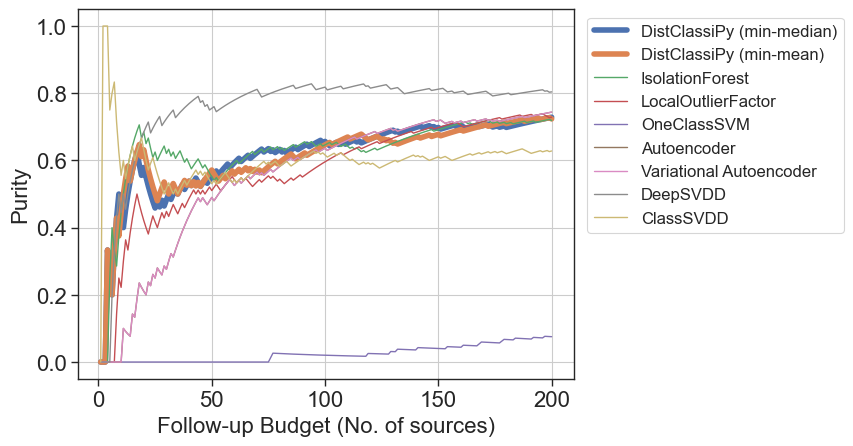

Knowns: ['QSO', 'YSO', 'Blazar', 'CV/Nova']
Unknowns: ['AGN']


Models:   0%|          | 0/9 [00:00<?, ?it/s]

Training AE:   0%|          | 0/200 [00:00<?, ?it/s]

Early stopping triggered.


Training VAE:   0%|          | 0/200 [00:00<?, ?it/s]

...

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

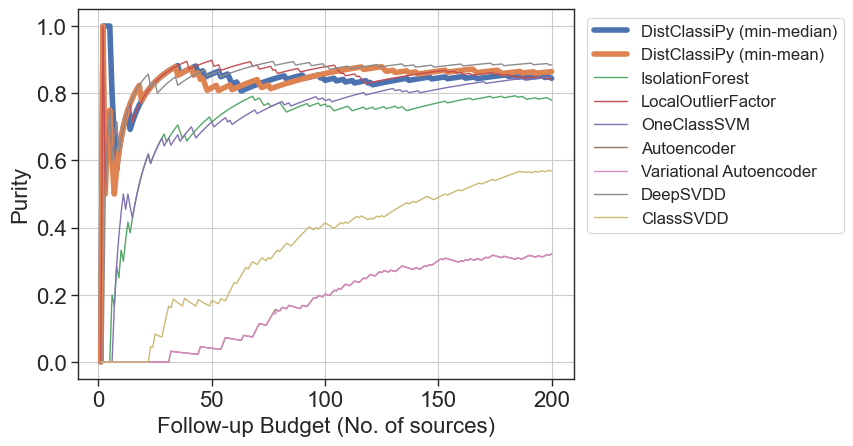

Knowns: ['QSO', 'YSO', 'AGN', 'CV/Nova']
Unknowns: ['Blazar']


Models:   0%|          | 0/9 [00:00<?, ?it/s]

Training AE:   0%|          | 0/200 [00:00<?, ?it/s]

Early stopping triggered.


Training VAE:   0%|          | 0/200 [00:00<?, ?it/s]

...

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

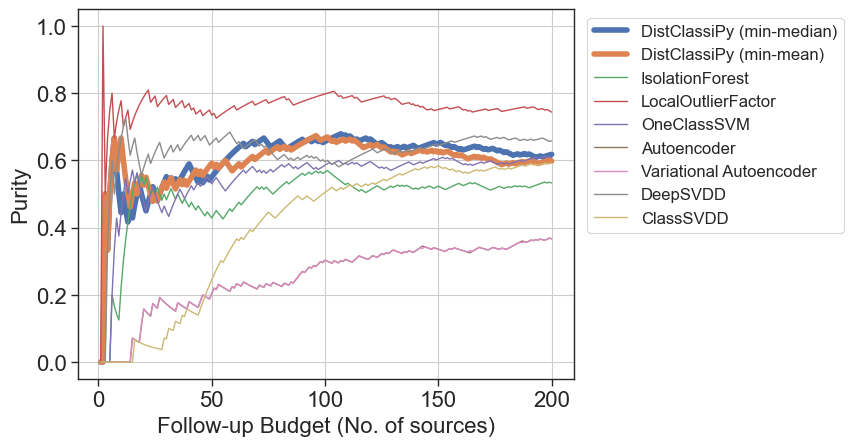

Knowns: ['QSO', 'YSO', 'AGN', 'Blazar']
Unknowns: ['CV/Nova']


Models:   0%|          | 0/9 [00:00<?, ?it/s]

Training AE:   0%|          | 0/200 [00:00<?, ?it/s]

Early stopping triggered.


Training VAE:   0%|          | 0/200 [00:00<?, ?it/s]

...

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

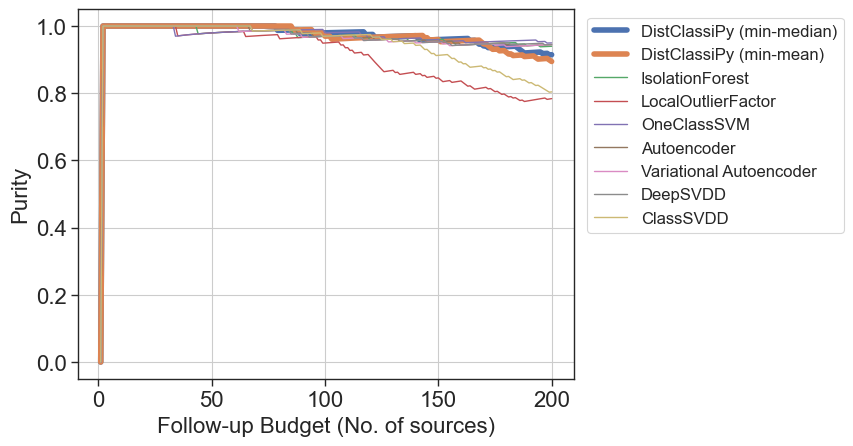

******************** Periodic ********************
Knowns: ['DSCT', 'E', 'RRL', 'LPV']
Unknowns: ['CEP']


Models:   0%|          | 0/9 [00:00<?, ?it/s]

Training AE:   0%|          | 0/200 [00:00<?, ?it/s]

Early stopping triggered.


Training VAE:   0%|          | 0/200 [00:00<?, ?it/s]

...

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

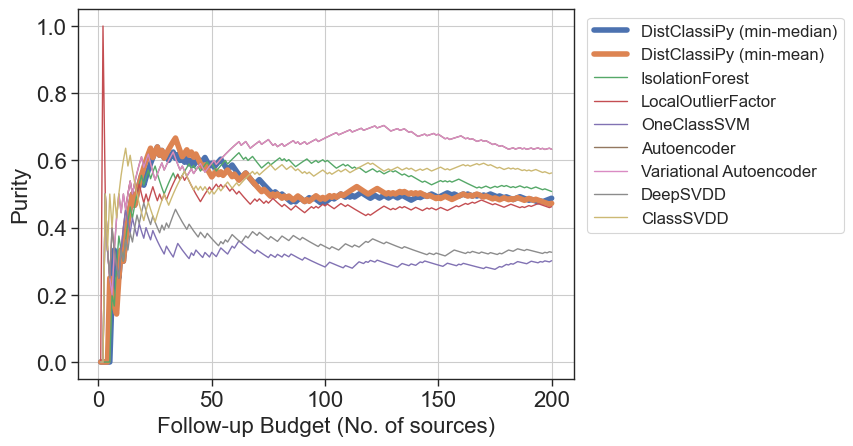

Knowns: ['CEP', 'E', 'RRL', 'LPV']
Unknowns: ['DSCT']


Models:   0%|          | 0/9 [00:00<?, ?it/s]

Training AE:   0%|          | 0/200 [00:00<?, ?it/s]

Early stopping triggered.


Training VAE:   0%|          | 0/200 [00:00<?, ?it/s]

...

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

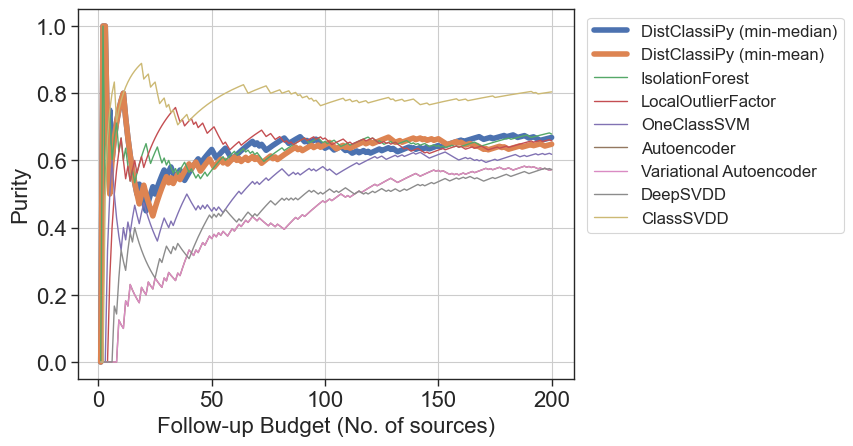

Knowns: ['CEP', 'DSCT', 'RRL', 'LPV']
Unknowns: ['E']


Models:   0%|          | 0/9 [00:00<?, ?it/s]

Training AE:   0%|          | 0/200 [00:00<?, ?it/s]

Early stopping triggered.


Training VAE:   0%|          | 0/200 [00:00<?, ?it/s]

...

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

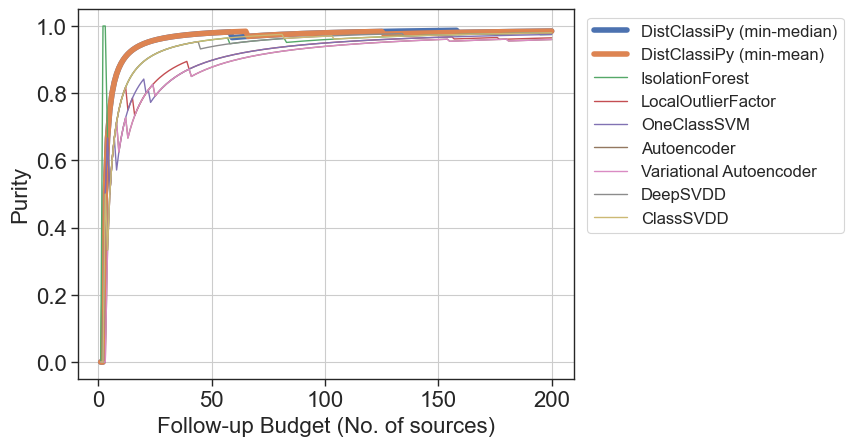

Knowns: ['CEP', 'DSCT', 'E', 'LPV']
Unknowns: ['RRL']


Models:   0%|          | 0/9 [00:00<?, ?it/s]

Training AE:   0%|          | 0/200 [00:00<?, ?it/s]

Early stopping triggered.


Training VAE:   0%|          | 0/200 [00:00<?, ?it/s]

...

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

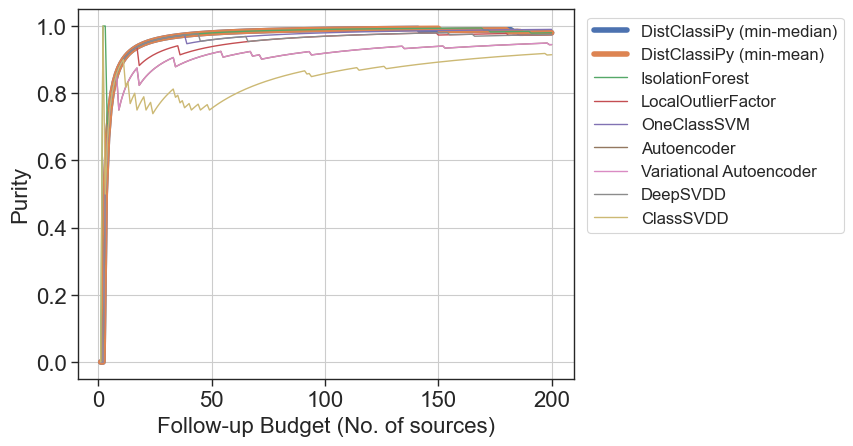

Knowns: ['CEP', 'DSCT', 'E', 'RRL']
Unknowns: ['LPV']


Models:   0%|          | 0/9 [00:00<?, ?it/s]

Training AE:   0%|          | 0/200 [00:00<?, ?it/s]

Early stopping triggered.


Training VAE:   0%|          | 0/200 [00:00<?, ?it/s]

...

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

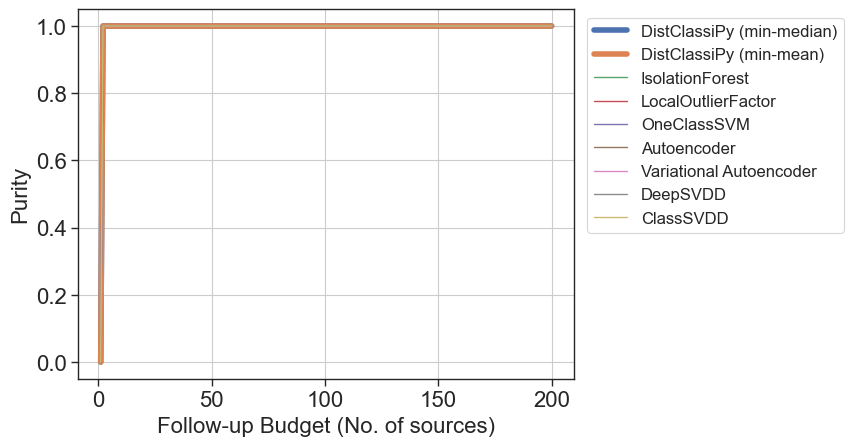

******************** All ********************
Knowns: ['SNII', 'SNIa', 'SNIbc', 'QSO', 'YSO', 'AGN', 'Blazar', 'CV/Nova', 'CEP', 'DSCT', 'E', 'RRL', 'LPV']
Unknowns: ['SLSN']


Models:   0%|          | 0/9 [00:00<?, ?it/s]

Training AE:   0%|          | 0/200 [00:00<?, ?it/s]

Early stopping triggered.


Training VAE:   0%|          | 0/200 [00:00<?, ?it/s]

...

  0%|          | 0/75 [00:00<?, ?it/s]

  0%|          | 0/75 [00:00<?, ?it/s]

  0%|          | 0/75 [00:00<?, ?it/s]

  0%|          | 0/75 [00:00<?, ?it/s]

  0%|          | 0/75 [00:00<?, ?it/s]

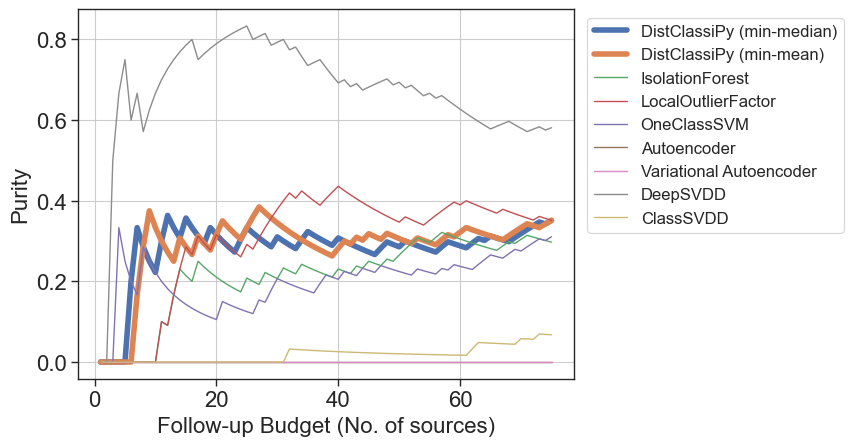

Knowns: ['SLSN', 'SNIa', 'SNIbc', 'QSO', 'YSO', 'AGN', 'Blazar', 'CV/Nova', 'CEP', 'DSCT', 'E', 'RRL', 'LPV']
Unknowns: ['SNII']


Models:   0%|          | 0/9 [00:00<?, ?it/s]

Training AE:   0%|          | 0/200 [00:00<?, ?it/s]

Early stopping triggered.


Training VAE:   0%|          | 0/200 [00:00<?, ?it/s]

...

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

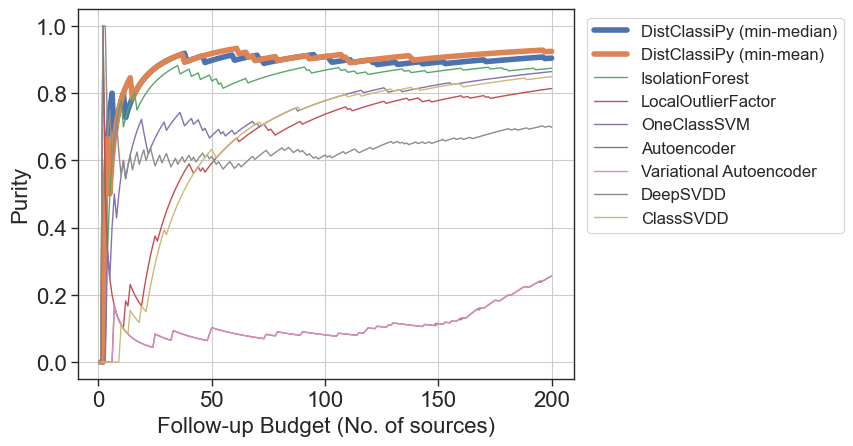

Knowns: ['SLSN', 'SNII', 'SNIbc', 'QSO', 'YSO', 'AGN', 'Blazar', 'CV/Nova', 'CEP', 'DSCT', 'E', 'RRL', 'LPV']
Unknowns: ['SNIa']


Models:   0%|          | 0/9 [00:00<?, ?it/s]

Training AE:   0%|          | 0/200 [00:00<?, ?it/s]

Early stopping triggered.


Training VAE:   0%|          | 0/200 [00:00<?, ?it/s]

...

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

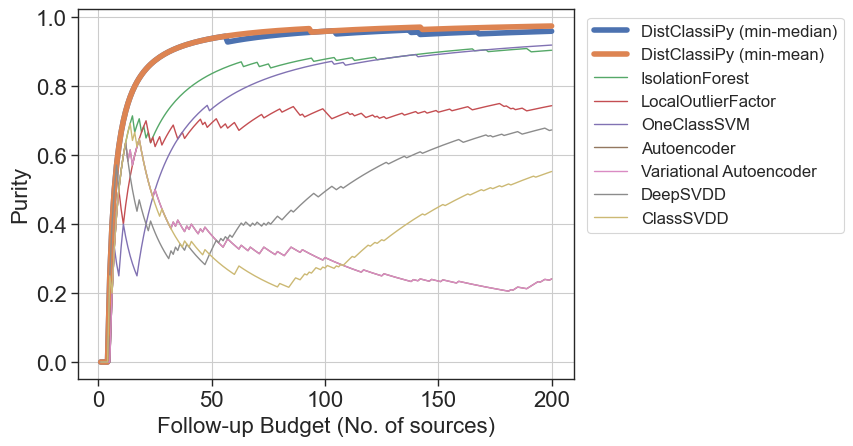

Knowns: ['SLSN', 'SNII', 'SNIa', 'QSO', 'YSO', 'AGN', 'Blazar', 'CV/Nova', 'CEP', 'DSCT', 'E', 'RRL', 'LPV']
Unknowns: ['SNIbc']


Models:   0%|          | 0/9 [00:00<?, ?it/s]

Training AE:   0%|          | 0/200 [00:00<?, ?it/s]

Early stopping triggered.


Training VAE:   0%|          | 0/200 [00:00<?, ?it/s]

...

  0%|          | 0/131 [00:00<?, ?it/s]

  0%|          | 0/131 [00:00<?, ?it/s]

  0%|          | 0/131 [00:00<?, ?it/s]

  0%|          | 0/131 [00:00<?, ?it/s]

  0%|          | 0/131 [00:00<?, ?it/s]

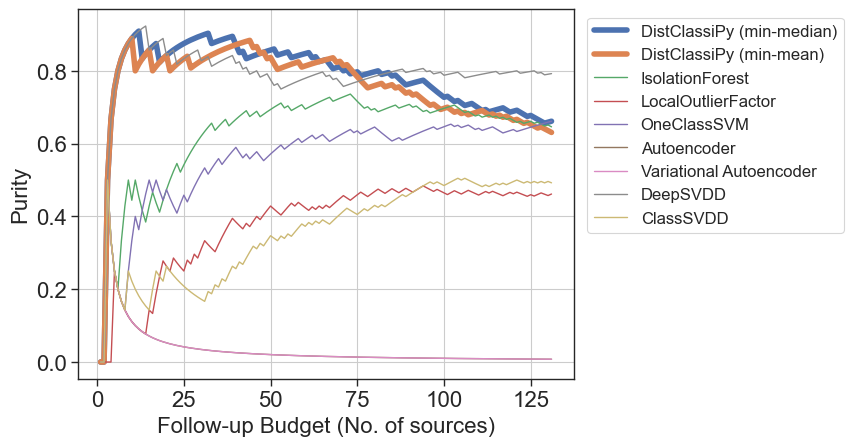

Knowns: ['SLSN', 'SNII', 'SNIa', 'SNIbc', 'YSO', 'AGN', 'Blazar', 'CV/Nova', 'CEP', 'DSCT', 'E', 'RRL', 'LPV']
Unknowns: ['QSO']


Models:   0%|          | 0/9 [00:00<?, ?it/s]

Training AE:   0%|          | 0/200 [00:00<?, ?it/s]

Early stopping triggered.


Training VAE:   0%|          | 0/200 [00:00<?, ?it/s]

...

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

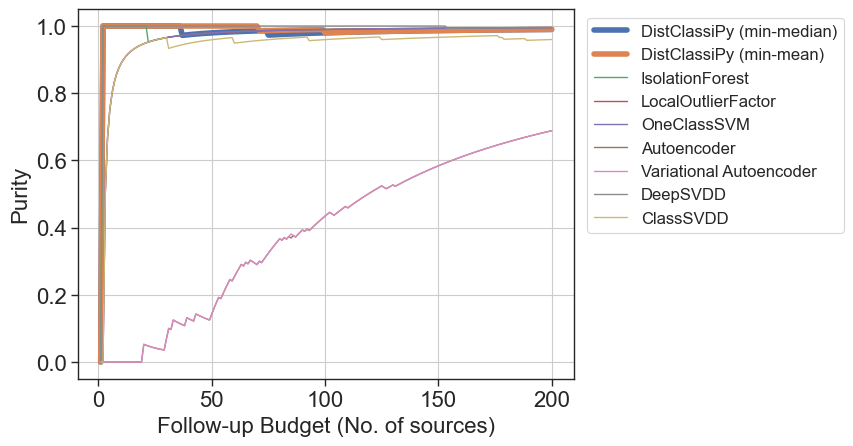

Knowns: ['SLSN', 'SNII', 'SNIa', 'SNIbc', 'QSO', 'AGN', 'Blazar', 'CV/Nova', 'CEP', 'DSCT', 'E', 'RRL', 'LPV']
Unknowns: ['YSO']


Models:   0%|          | 0/9 [00:00<?, ?it/s]

Training AE:   0%|          | 0/200 [00:00<?, ?it/s]

Early stopping triggered.


Training VAE:   0%|          | 0/200 [00:00<?, ?it/s]

...

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

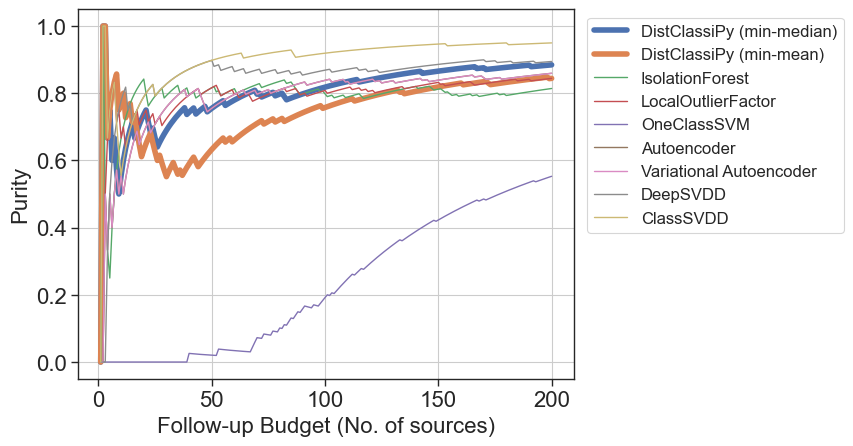

Knowns: ['SLSN', 'SNII', 'SNIa', 'SNIbc', 'QSO', 'YSO', 'Blazar', 'CV/Nova', 'CEP', 'DSCT', 'E', 'RRL', 'LPV']
Unknowns: ['AGN']


Models:   0%|          | 0/9 [00:00<?, ?it/s]

Training AE:   0%|          | 0/200 [00:00<?, ?it/s]

Early stopping triggered.


Training VAE:   0%|          | 0/200 [00:00<?, ?it/s]

...

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

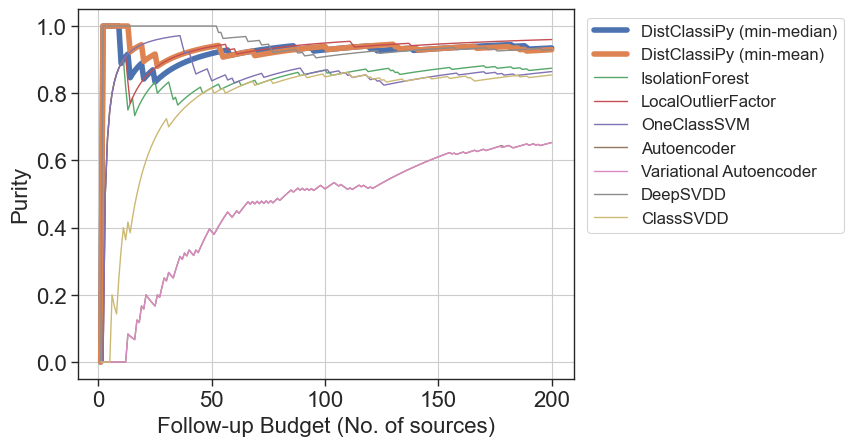

Knowns: ['SLSN', 'SNII', 'SNIa', 'SNIbc', 'QSO', 'YSO', 'AGN', 'CV/Nova', 'CEP', 'DSCT', 'E', 'RRL', 'LPV']
Unknowns: ['Blazar']


Models:   0%|          | 0/9 [00:00<?, ?it/s]

Training AE:   0%|          | 0/200 [00:00<?, ?it/s]

Early stopping triggered.


Training VAE:   0%|          | 0/200 [00:00<?, ?it/s]

...

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

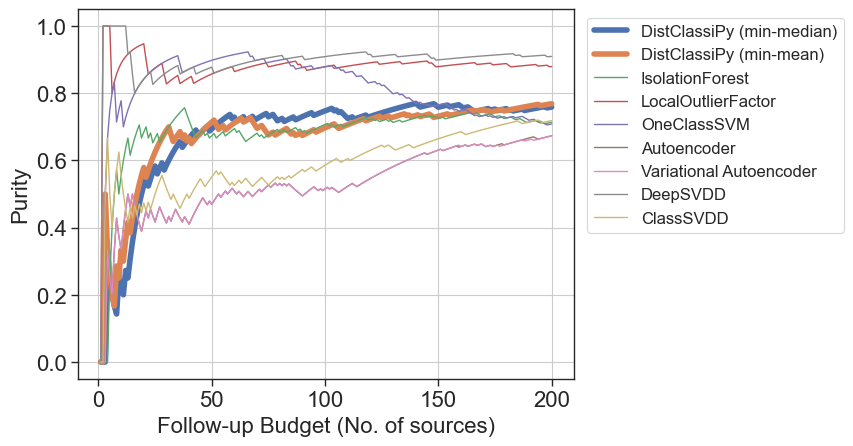

Knowns: ['SLSN', 'SNII', 'SNIa', 'SNIbc', 'QSO', 'YSO', 'AGN', 'Blazar', 'CEP', 'DSCT', 'E', 'RRL', 'LPV']
Unknowns: ['CV/Nova']


Models:   0%|          | 0/9 [00:00<?, ?it/s]

Training AE:   0%|          | 0/200 [00:00<?, ?it/s]

Early stopping triggered.


Training VAE:   0%|          | 0/200 [00:00<?, ?it/s]

...

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

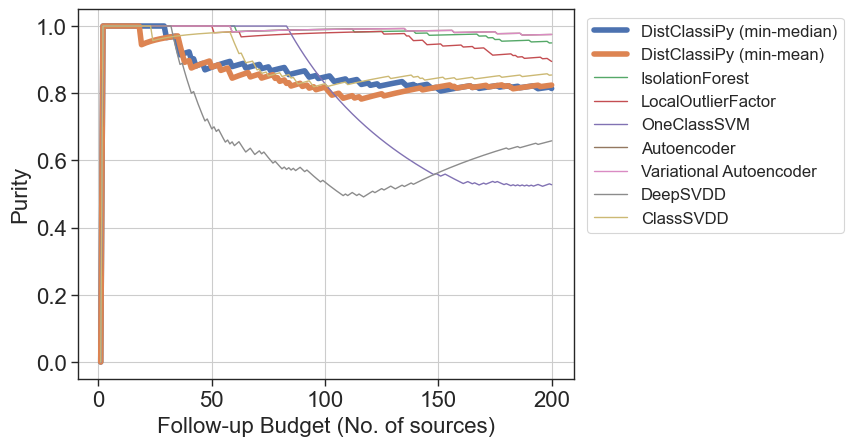

Knowns: ['SLSN', 'SNII', 'SNIa', 'SNIbc', 'QSO', 'YSO', 'AGN', 'Blazar', 'CV/Nova', 'DSCT', 'E', 'RRL', 'LPV']
Unknowns: ['CEP']


Models:   0%|          | 0/9 [00:00<?, ?it/s]

Training AE:   0%|          | 0/200 [00:00<?, ?it/s]

Early stopping triggered.


Training VAE:   0%|          | 0/200 [00:00<?, ?it/s]

...

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

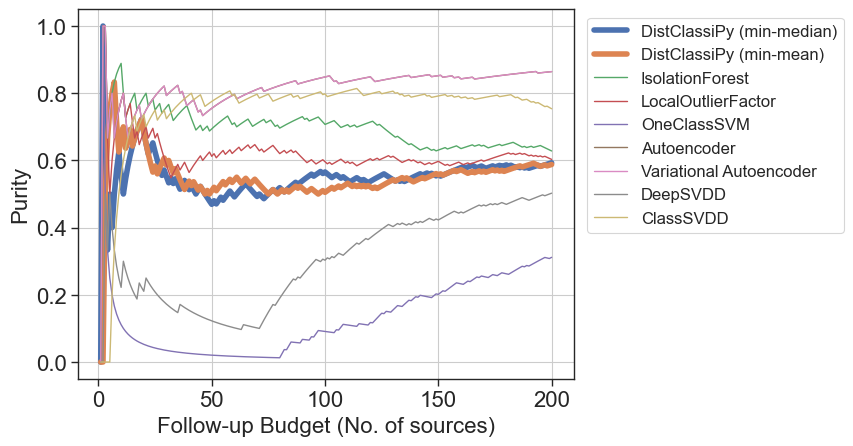

Knowns: ['SLSN', 'SNII', 'SNIa', 'SNIbc', 'QSO', 'YSO', 'AGN', 'Blazar', 'CV/Nova', 'CEP', 'E', 'RRL', 'LPV']
Unknowns: ['DSCT']


Models:   0%|          | 0/9 [00:00<?, ?it/s]

Training AE:   0%|          | 0/200 [00:00<?, ?it/s]

Early stopping triggered.


Training VAE:   0%|          | 0/200 [00:00<?, ?it/s]

...

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

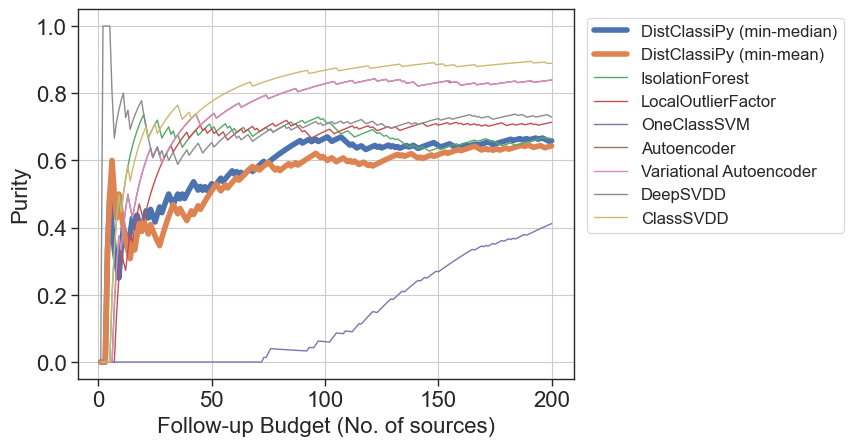

Knowns: ['SLSN', 'SNII', 'SNIa', 'SNIbc', 'QSO', 'YSO', 'AGN', 'Blazar', 'CV/Nova', 'CEP', 'DSCT', 'RRL', 'LPV']
Unknowns: ['E']


Models:   0%|          | 0/9 [00:00<?, ?it/s]

Training AE:   0%|          | 0/200 [00:00<?, ?it/s]

Early stopping triggered.


Training VAE:   0%|          | 0/200 [00:00<?, ?it/s]

...

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

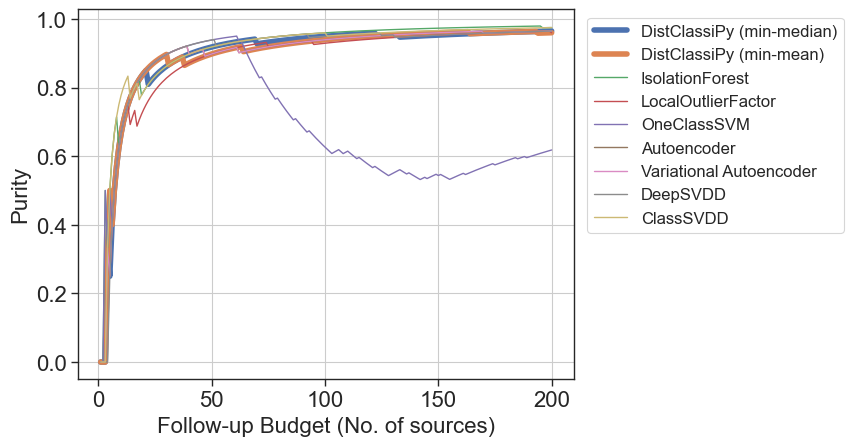

Knowns: ['SLSN', 'SNII', 'SNIa', 'SNIbc', 'QSO', 'YSO', 'AGN', 'Blazar', 'CV/Nova', 'CEP', 'DSCT', 'E', 'LPV']
Unknowns: ['RRL']


Models:   0%|          | 0/9 [00:00<?, ?it/s]

Training AE:   0%|          | 0/200 [00:00<?, ?it/s]

Early stopping triggered.


Training VAE:   0%|          | 0/200 [00:00<?, ?it/s]

...

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

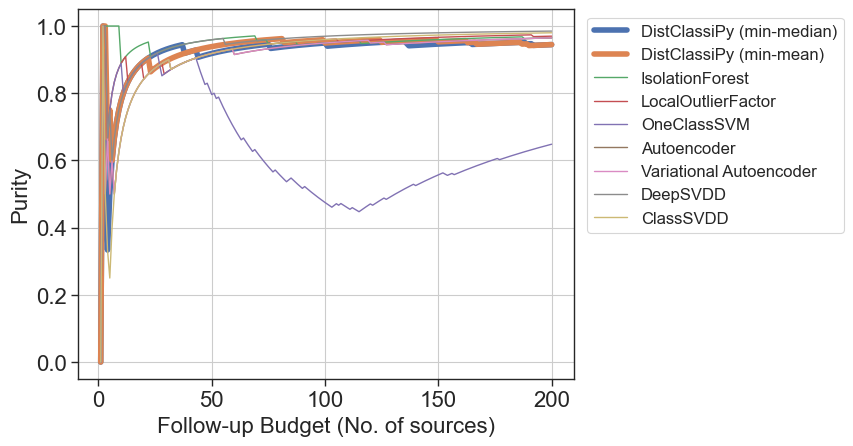

Knowns: ['SLSN', 'SNII', 'SNIa', 'SNIbc', 'QSO', 'YSO', 'AGN', 'Blazar', 'CV/Nova', 'CEP', 'DSCT', 'E', 'RRL']
Unknowns: ['LPV']


Models:   0%|          | 0/9 [00:00<?, ?it/s]

Training AE:   0%|          | 0/200 [00:00<?, ?it/s]

Early stopping triggered.


Training VAE:   0%|          | 0/200 [00:00<?, ?it/s]

...

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

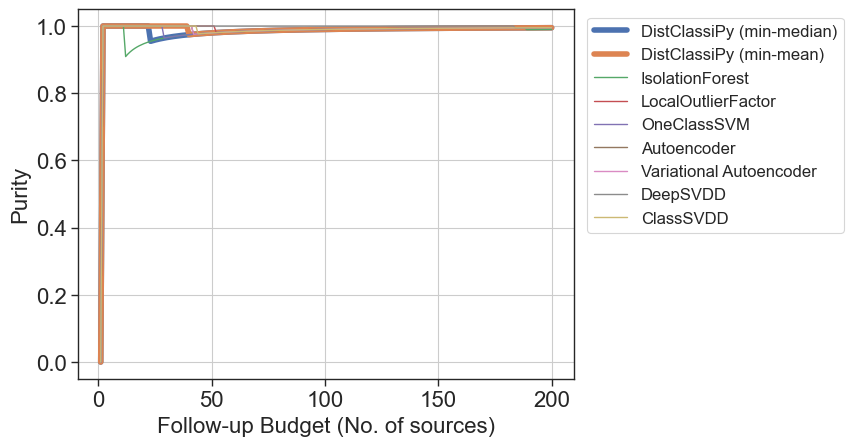

In [7]:
for top_level_class, subclasses in alerce_taxonomy.items():
    print("*"*20, top_level_class, "*"*20)
    for anomaly_subclass in subclasses:
        myunknowns = [anomaly_subclass]
        myknowns = [cl for cl in subclasses if cl!=anomaly_subclass]
        print(f"Knowns: {myknowns}")
        print(f"Unknowns: {myunknowns}")

        results_df = run_anom_exp(
            new_knowns=myknowns, 
            new_unknowns=myunknowns,
            features_to_use=myfeatures,
            std_scale=False,
            rebalance_knowns=True,
        )
        
        analysis(results_df, min_to_plot=200)
        plt.show()